# About Dataset
## Context
The story behind this datasets is how lock-down affects employment opportunities and how the unemployment rate increases during the Covid-19.

## Content
This dataset contains the unemployment rate of all the states in India

- Region = states in India
- Date = date which the unemployment rate observed
- Frequency = measuring frequency (Monthly)
- Estimated Unemployment Rate (%) = percentage of people unemployed in each States of India
- Estimated Employed = percentage of people employed
- Estimated Labour Participation Rate (%) = labour force participation rate by dividing the number of people        actively participating in the labour force by the
total number of people eligible to participate in the labor force
force

Inspiration
questions?

- How Covid-19 affects the employment
- how far the unemployment rate will go
- 
source of datasets
https://unemploymentinindia.cmie.com/

Kaggle dataset link
https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india

- Import the required libraries
- libraries for data analysis and visualization

- ============================================================
- UNEMPLOYMENT IN INDIA: THE LOCKDOWN SHOCK AND THE SLOW RECOVERY
- A state-level deep dive into the 2020 labour market collapse
- Author: Mohsin Shareef
- Dataset: Unemployment_Rate_upto_11_2020.csv (CMIE via Kaggle)
- ============================================================

In [45]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# --- Visual style: clean, readable, not the default seaborn ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("RdBu_r")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'figure.dpi': 100
})



# display all columns
pd.set_option('display.max_columns', None)
# display all rows
pd.set_option('display.max_rows', None)
# set float display format to two decimal places
# pd.options.display.float_format = '{:.2f}'.format

- We have 2 datasets, one for the unemployment rate upto 11 2020, and another for the Unemployment in India.
- Both of the datasets are in CSV format, so we can read them using the read_csv function
- We work with Unemployment_Rate_Upto_11_2020.

In [2]:
df_ur = pd.read_csv('unemployment_Rate_upto_11_2020.csv') # df_ur means DataFrame Unemployment Rate

In [3]:
df_ur.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
df_ur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


- In Umployment Rate dataset, the columns are Region, Date, Frequency, Estimated Unemployment Rate (%), Estimated Employed, Estimated Labour Participation Rate (%), Region.1, longitude, latitude.
- In Unemployment Rate dataset have 267 rows and 9 columns.
- The first thing i saw unnecessary spaces in the columns names.
- Date datatype is object and we need to change it to datetime.

In [5]:
# To confirm, i will check the column names to see if they contain spaces?
df_ur.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

- columns names have spaces in them and this is a problem when we call the columns names.
- so we need to remove the spaces from the column names.

In [6]:
df_ur.columns = df_ur.columns.str.strip()

- Now summarize the data using describe() function.

In [7]:
df_ur.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


- Describe function is used to get the summary of the data. by default it gives the summary of numeric columns.
- statistics summary is contains mean, std, min, max, 25%, 50%, 75% of the data.
- Estimated Unemployment Rate (%) mean is 12.24, std is 10.80, min is 0.50, and max is 75.85.
- Estimated Employed mean is 13962105.72, std is 13366318.36, min is 117542.00, and max is 59433759.00.
- Estimated Labour Participation Rate (%) mean is 41.68, std is 7.85, min is 16.77, and max is 33.78.
- logitude, and latitude are coordinates use for map location of the states.

- Rename columns to something workable.

In [8]:
rename_map = {
    'Region': 'State',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'LFPR',
    'Region.1': 'Zone'
}

df_ur = df_ur.rename(columns=rename_map)

In [9]:
df_ur.head()

,State,Date,Frequency,Unemployment_Rate,Employed,LFPR,Zone,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


- Investigate the columns one by one.

In [10]:
print(df_ur['State'].nunique())
df_ur['State'].unique()

27


array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal'], dtype=object)

- State column has 27 unique values means 27 states.
- Check the value_counts of the State column.

In [11]:
df_ur['State'].value_counts().head()

State
Andhra Pradesh    10
Assam             10
Uttarakhand       10
Uttar Pradesh     10
Tripura           10
Name: count, dtype: int64

- All states is 10 value counsts except 2 Jammu and Kashmir 9 and Sikkim 8.

- Now we have to change the Date column datatype from object to datetime.
- Than check tha duration of the unemployment rate data.

In [12]:
df_ur['Date'] = pd.to_datetime(df_ur['Date'])

In [13]:
print(df_ur['Date'].min())
print(df_ur['Date'].max())

2020-01-31 00:00:00
2020-10-31 00:00:00


In [26]:
# create a new column year month day
df_ur['year'] = df_ur['Date'].dt.year
df_ur['month'] = df_ur['Date'].dt.month
df_ur['day'] = df_ur['Date'].dt.day
# create a new column for month name
df_ur['month_name'] = df_ur['Date'].dt.month_name()

In [15]:
print(f"Number of unique days:{df_ur['day'].nunique()}")
print(f"display day:{df_ur['day'].unique()}")
print(f" Number of unique months:{df_ur['month'].nunique()}")
print(f" display month:{df_ur['month'].unique()}")
print(f" Number of unique years:{df_ur['year'].nunique()}")
print(f" display year:{df_ur['year'].unique()}")

Number of unique days:3
display day:[31 29 30]
 Number of unique months:10
 display month:[ 1  2  3  4  5  6  7  8  9 10]
 Number of unique years:1
 display year:[2020]


- This data is from 2020-01-31 to 2020-10-31.
- Almost 10 months of data.
- create new column for Date column Year, Month, Day.

- Now see the frequency column.

In [16]:
df_ur['Frequency'].value_counts()

Frequency
M    267
Name: count, dtype: int64

In [ ]:
# drop frequency column
df_ur = df_ur.drop(columns=['Frequency'])

,State,Date,Unemployment_Rate,Employed,LFPR,Zone,longitude,latitude,year,month,day
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74,2020,1,31
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74,2020,2,29
2,Andhra Pradesh,2020-03-31,5.79,15881197,39.18,South,15.9129,79.74,2020,3,31
3,Andhra Pradesh,2020-04-30,20.51,11336911,33.10,South,15.9129,79.74,2020,4,30
4,Andhra Pradesh,2020-05-31,17.43,12988845,36.46,South,15.9129,79.74,2020,5,31


- Frequency column has only one value M means monthly.
- This is not required for the analysis simply drop the column.
- Investigate the Zone column.

In [18]:
df_ur['Zone'].value_counts()

Zone
North        79
South        60
West         50
East         40
Northeast    38
Name: count, dtype: int64

In [19]:
print(df_ur['longitude'].nunique())
print(df_ur['longitude'].unique())
print(50* "-")
print(df_ur['latitude'].nunique())
print(df_ur['latitude'].unique())

27
[15.9129 26.2006 25.0961 21.2787 28.7041 15.2993 22.2587 29.0588 31.1048
 33.7782 23.6102 15.3173 10.8505 22.9734 19.7515 25.467  20.9517 11.9416
 31.1471 27.0238 27.533  11.1271 18.1124 23.9408 26.8467 30.0668 22.9868]
--------------------------------------------------
24
[79.74   92.9376 85.3131 81.8661 77.1025 74.124  71.1924 76.0856 77.1734
 76.5762 85.2799 75.7139 76.2711 78.6569 91.3662 85.0985 79.8083 75.3412
 74.2179 88.5122 79.0193 91.9882 80.9462 87.855 ]


- Zone column has Longitude 27 unique values and 27 states.
- Zone column has Latitude 24 unique values and 27 states.
- Investigate why latitude 24 values.
- Check the value_counts of the latitude column.

In [20]:
df_ur['latitude'].value_counts().head()

latitude
79.0193    20
78.6569    20
75.7139    20
79.7400    10
92.9376    10
Name: count, dtype: int64

In [21]:
df_ur[df_ur['latitude'] ==  79.0193]

,State,Date,Unemployment_Rate,Employed,LFPR,Zone,longitude,latitude,year,month,day
217,Telangana,2020-01-31,5.49,17609295,59.25,South,18.1124,79.0193,2020,1,31
218,Telangana,2020-02-29,8.29,16825970,58.24,South,18.1124,79.0193,2020,2,29
219,Telangana,2020-03-31,5.77,17341613,58.31,South,18.1124,79.0193,2020,3,31
220,Telangana,2020-04-30,6.25,12172230,41.06,South,18.1124,79.0193,2020,4,30
221,Telangana,2020-05-31,14.70,14977774,55.43,South,18.1124,79.0193,2020,5,31
222,Telangana,2020-06-30,10.55,15108910,53.22,South,18.1124,79.0193,2020,6,30
223,Telangana,2020-07-31,5.36,15679417,52.10,South,18.1124,79.0193,2020,7,31
224,Telangana,2020-08-31,5.79,18185429,60.59,South,18.1124,79.0193,2020,8,31
225,Telangana,2020-09-30,3.27,16961448,54.94,South,18.1124,79.0193,2020,9,30
226,Telangana,2020-10-31,2.86,17578739,56.58,South,18.1124,79.0193,2020,10,31


- Telangana and Uttarakhand has same latitude 79.0193.
- Madhya Pradesh and Tamil Nadu has same latitude 78.6569.
- Karnataka and Maharashtra has same latitude 75.7139.


- Now check the Missing values and duplicates.

In [22]:
# missing values
df_ur.isnull().sum() * len(df_ur) / 100

State                0.0
Date                 0.0
Unemployment_Rate    0.0
Employed             0.0
LFPR                 0.0
Zone                 0.0
longitude            0.0
latitude             0.0
year                 0.0
month                0.0
day                  0.0
dtype: float64

In [23]:
# duplicate values
df_ur.duplicated().sum()

np.int64(0)

In [24]:
df_ur.head()

,State,Date,Unemployment_Rate,Employed,LFPR,Zone,longitude,latitude,year,month,day
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74,2020,1,31
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74,2020,2,29
2,Andhra Pradesh,2020-03-31,5.79,15881197,39.18,South,15.9129,79.74,2020,3,31
3,Andhra Pradesh,2020-04-30,20.51,11336911,33.10,South,15.9129,79.74,2020,4,30
4,Andhra Pradesh,2020-05-31,17.43,12988845,36.46,South,15.9129,79.74,2020,5,31


- Now we will make a Line plot of the unemployment rate in India.
- First make a plot of Unemployment_Rate.

In [28]:
df_ur.head(1)

,State,Date,Unemployment_Rate,Employed,LFPR,Zone,longitude,latitude,year,month,day,month_name
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74,2020,1,31,January


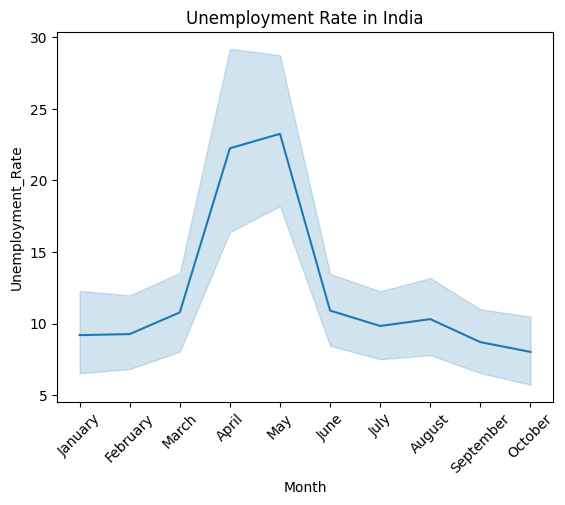

In [ ]:
# make a plot of unemployment rate
sns.lineplot(x='month_name', y='Unemployment_Rate', data=df_ur)
plt.xlabel('Month')
plt.ylabel('Unemployment_Rate')
plt.xticks(rotation=45)
plt.title('Unemployment Rate in India')
plt.show()

- According to the plot, the unemployment rate is increasing from March to May.
- Now make a plot of Estimated Employed.
- Can show the opposite trend.

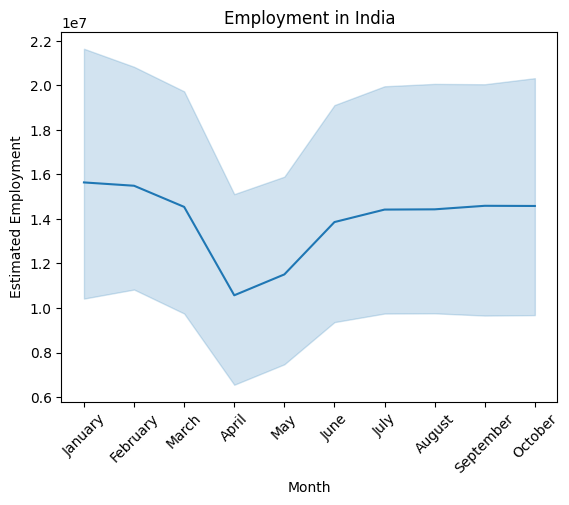

In [32]:
# make a plot of  Employed
sns.lineplot(x='month_name', y='Employed', data=df_ur)
plt.xlabel('Month')
plt.ylabel('Estimated Employment')
plt.xticks(rotation=45)
plt.title('Employment in India')
plt.show()

- we clearly see the trend of Employment.
- March to May employment rate is decreased.
- Now make a plot of LFPR (Estimated Labour Participation Rate (%)).

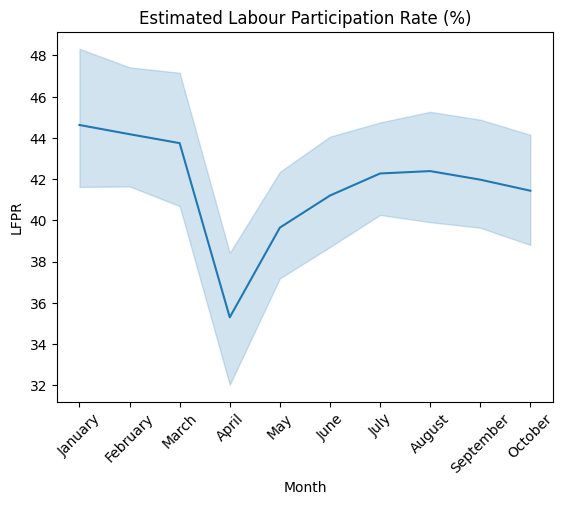

In [34]:
# make a plot of Estimated Employed
sns.lineplot(x='month_name', y='LFPR', data=df_ur)
plt.xlabel('Month')
plt.ylabel('LFPR')
plt.xticks(rotation=45)
plt.title('Estimated Labour Participation Rate (%)')
plt.show()

- Estimated Labour Participation Rate (%) is sharply decreased in April.
- During the Covid-19, Labour Participation Rate is decreased.

In [35]:
df_ur.head()

,State,Date,Unemployment_Rate,Employed,LFPR,Zone,longitude,latitude,year,month,day,month_name
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74,2020,1,31,January
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74,2020,2,29,February
2,Andhra Pradesh,2020-03-31,5.79,15881197,39.18,South,15.9129,79.74,2020,3,31,March
3,Andhra Pradesh,2020-04-30,20.51,11336911,33.10,South,15.9129,79.74,2020,4,30,April
4,Andhra Pradesh,2020-05-31,17.43,12988845,36.46,South,15.9129,79.74,2020,5,31,May


- Tell the highest unemployment rate in Zone and State.
- Now we will make a Sunburst plot of the unemployment rate in India.

In [38]:
import plotly.express as px

fig = px.sunburst(
    df_ur,
    path=['Zone', 'State'],
    values='Unemployment_Rate',
    color='Zone'
)
fig.show()

- Top 10 states with highest unemployment rate according to this data.

In [39]:
# highest unemployment rate in region
df_ur.groupby('State')['Unemployment_Rate'].max().head(10)

State
Andhra Pradesh      20.51
Assam               11.06
Bihar               46.64
Chhattisgarh        14.23
Delhi               42.27
Goa                 21.25
Gujarat             18.71
Haryana             43.22
Himachal Pradesh    26.95
Jammu & Kashmir     21.08
Name: Unemployment_Rate, dtype: float64

In [40]:
# highest unemployment rate in Zone
df_ur.groupby('Zone')['Unemployment_Rate'].max()

Zone
East         59.23
North        43.22
Northeast    41.23
South        75.85
West         21.98
Name: Unemployment_Rate, dtype: float64

- India's lockdown was announced on 25 March 2020.
- We'll use this as a reference point for everything that follows.
- We are going to advanced level analysis by creating a pre-lockdown and post-lockdown unemployment rate.

In [41]:


lockdown_date = pd.Timestamp('2020-03-25')

# Create a phase label
def label_phase(row):
    if row['Date'] < lockdown_date:
        return 'Pre-Lockdown'
    else:
        return 'Post-Lockdown'

df_ur['Phase'] = df_ur.apply(label_phase, axis=1)

# Quick count by phase
print(df_ur['Phase'].value_counts())

Phase
Post-Lockdown    215
Pre-Lockdown      52
Name: count, dtype: int64


In [51]:
df_ur.head()

,State,Date,Unemployment_Rate,Employed,LFPR,Zone,longitude,latitude,year,month,day,month_name,Phase
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74,2020,1,31,January,Pre-Lockdown
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74,2020,2,29,February,Pre-Lockdown
2,Andhra Pradesh,2020-03-31,5.79,15881197,39.18,South,15.9129,79.74,2020,3,31,March,Post-Lockdown
3,Andhra Pradesh,2020-04-30,20.51,11336911,33.10,South,15.9129,79.74,2020,4,30,April,Post-Lockdown
4,Andhra Pradesh,2020-05-31,17.43,12988845,36.46,South,15.9129,79.74,2020,5,31,May,Post-Lockdown


- Our main goal is to compare the unemployment rate before and after the lockdown.
- Now we will make a Line plot of the pre-lockdown and post-lockdown unemployment rate in India.

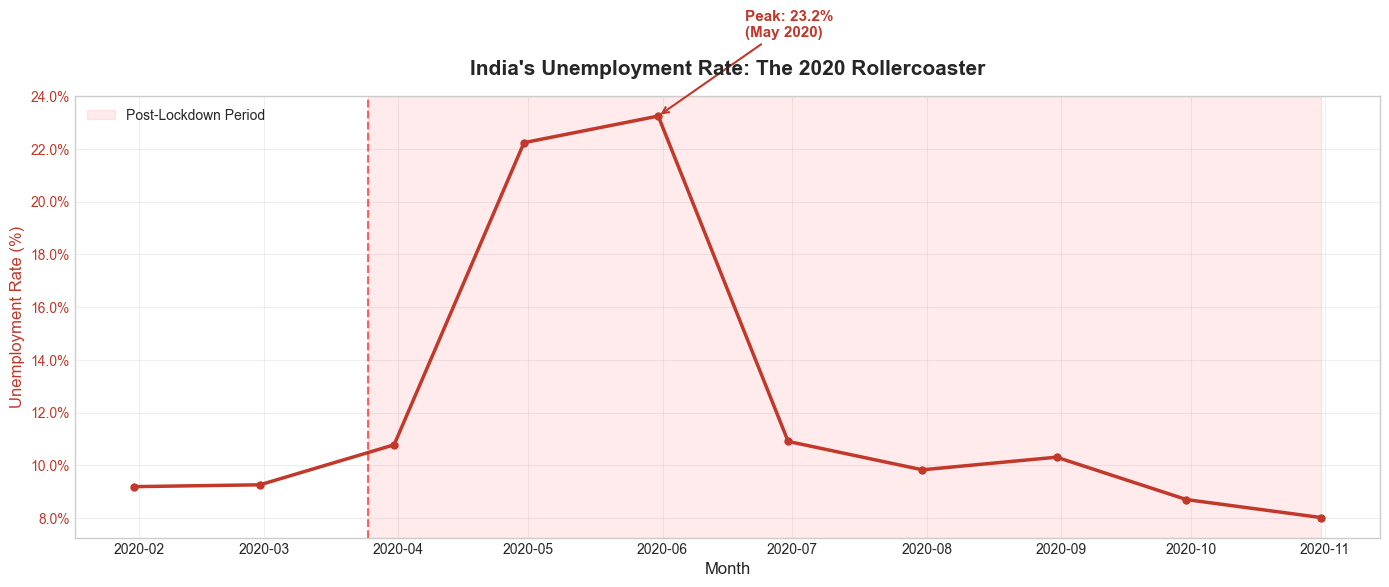

In [46]:

# Aggregate to national level (monthly mean across states)
national = df_ur.groupby('Date').agg({
    'Unemployment_Rate': 'mean',
    'Employed': 'sum',
    'LFPR': 'mean'
}).reset_index()

national['Month'] = national['Date'].dt.strftime('%b %Y')

fig, ax1 = plt.subplots(figsize=(14, 6))

color = '#c0392b'
ax1.plot(national['Date'], national['Unemployment_Rate'], color=color, linewidth=2.5, marker='o', markersize=5)
ax1.set_ylabel('Unemployment Rate (%)', color=color, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())

# Shade the lockdown period
ax1.axvspan(lockdown_date, national['Date'].max(), alpha=0.08, color='red', label='Post-Lockdown Period')
ax1.axvline(lockdown_date, color='red', linestyle='--', alpha=0.6, linewidth=1.5)

# Annotate the peak
peak_row = national.loc[national['Unemployment_Rate'].idxmax()]
ax1.annotate(f"Peak: {peak_row['Unemployment_Rate']:.1f}%\n({peak_row['Month']})",
             xy=(peak_row['Date'], peak_row['Unemployment_Rate']),
             xytext=(peak_row['Date'] + pd.Timedelta(days=20), peak_row['Unemployment_Rate'] + 3),
             fontsize=11, color='#c0392b', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax1.set_title('India\'s Unemployment Rate: The 2020 Rollercoaster', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Month', fontsize=12)
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Let's quantify the shock
pre = national[national['Date'] < lockdown_date]['Unemployment_Rate'].mean()
post_peak = national['Unemployment_Rate'].max()
increase = post_peak - pre

print(f"Pre-lockdown average unemployment rate: {pre:.2f}%")
print(f"Peak monthly unemployment rate: {post_peak:.2f}%")
print(f"Absolute increase: {increase:.2f} percentage points")
print(f"Relative increase: {(increase/pre)*100:.0f}%")

Pre-lockdown average unemployment rate: 9.23%
Peak monthly unemployment rate: 23.24%
Absolute increase: 14.01 percentage points
Relative increase: 152%


- pre lockdown average unemployment rate: 9.23%
- Peak monthly unemployment rate: 23.2%
- Absolute increase: 14.01 percentage points
- Relative increase: 152%

- Find the peak unemployment rate for each state.
- Now we will make a bar plot of the unemployment rate in India.
- The peak unemployment rate for each state by visualization.

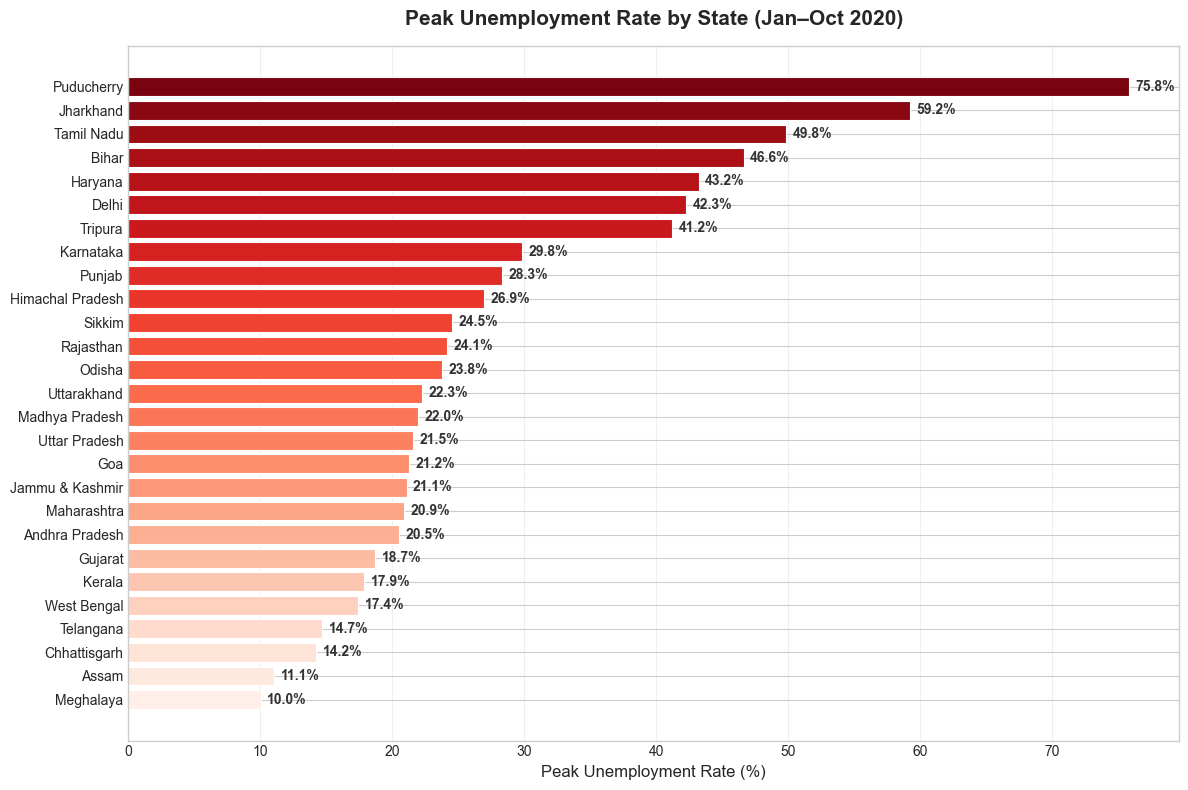

In [52]:

state_peak = df_ur.loc[df_ur.groupby('State')['Unemployment_Rate'].idxmax()]
state_peak = state_peak.sort_values('Unemployment_Rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette("Reds_r", n_colors=len(state_peak))
bars = ax.barh(state_peak['State'], state_peak['Unemployment_Rate'], color=colors, edgecolor='white', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, state_peak['Unemployment_Rate']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color='#333')

ax.set_xlabel('Peak Unemployment Rate (%)', fontsize=12)
ax.set_title('Peak Unemployment Rate by State (Jan–Oct 2020)', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

- Peak unemployment rate for each state by visualization.
- Higher unemployment rate in Puducherry 75.8%, Jharkhand 59.2%, Tamil Nadu 49.8%.
- Lower unemployment rate in Chhattisgarh 14.2%, Assam 11.1%, Meghalaya 10.0%.

- While everyone focuses on the unemployment rate, the LFPR tells a darker story:
- people didn't just lose jobs, they stopped looking for work altogether.

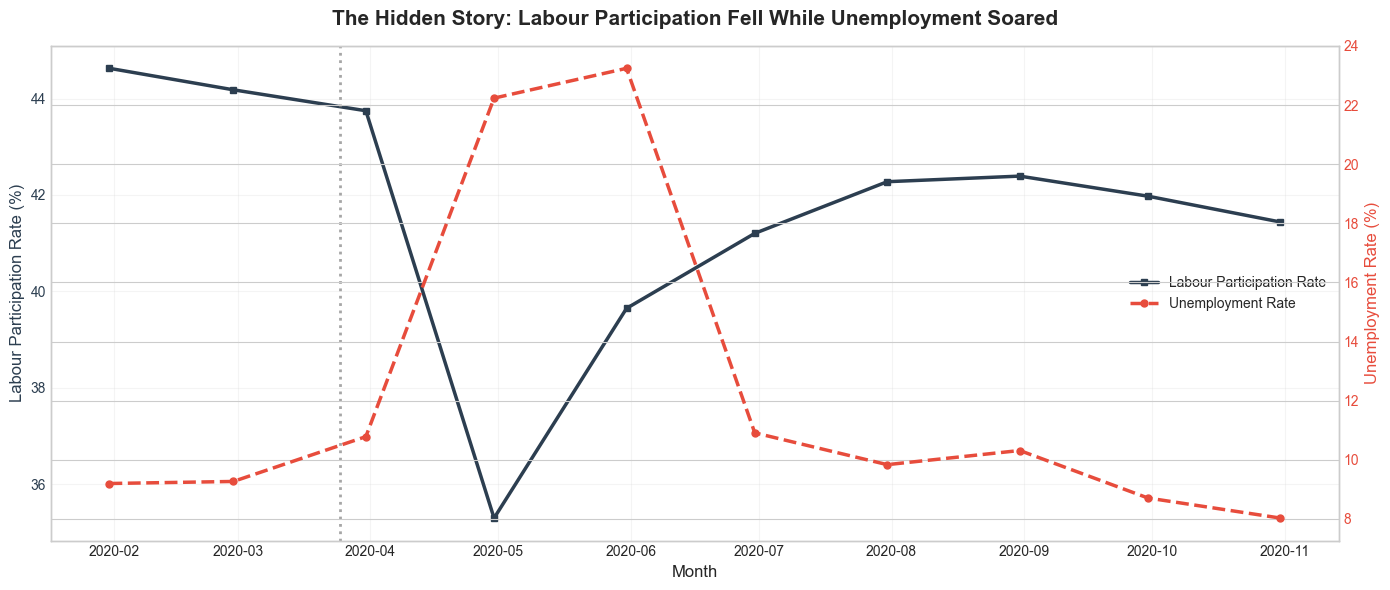

In [49]:

national_lfpr = df_ur.groupby('Date')['LFPR'].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#2c3e50'
color2 = '#e74c3c'

ax1.plot(national_lfpr['Date'], national_lfpr['LFPR'], color=color1, linewidth=2.5, marker='s', markersize=5, label='Labour Participation Rate')
ax1.set_ylabel('Labour Participation Rate (%)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(national['Date'], national['Unemployment_Rate'], color=color2, linewidth=2.5, marker='o', markersize=5, linestyle='--', label='Unemployment Rate')
ax2.set_ylabel('Unemployment Rate (%)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.axvline(lockdown_date, color='grey', linestyle=':', alpha=0.7, linewidth=2)

ax1.set_title('The Hidden Story: Labour Participation Fell While Unemployment Soared', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Month', fontsize=12)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', framealpha=0.9)

ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [50]:
# Quantify the LFPR drop
lfpr_pre = national_lfpr[national_lfpr['Date'] < lockdown_date]['LFPR'].mean()
lfpr_min = national_lfpr['LFPR'].min()
lfpr_drop = lfpr_pre - lfpr_min

print(f"Pre-lockdown average LFPR: {lfpr_pre:.2f}%")
print(f"Minimum LFPR during lockdown: {lfpr_min:.2f}%")
print(f"Drop: {lfpr_drop:.2f} percentage points")

Pre-lockdown average LFPR: 44.40%
Minimum LFPR during lockdown: 35.30%
Drop: 9.11 percentage points


- Pre-lockdown average LFPR: 44.40%.
- Minimum LFPR during lockdown: 35.0%.
- Drop: 9.11 percentage points.
- As the Unemployment rate rose, labor force participation rate declined.

## Thank you for spending your valuable time on my work.